In [ ]:
# Run this cell first (only needed on Colab / fresh envs)
!pip install numpy matplotlib opencv-python-headless scikit-image --quiet

# Lab 9: Sensor Simulation for Autonomy
## EE0849 Introduction to Robotics

In this lab you simulate a 2D LiDAR, build an occupancy grid from its scans, and then use OpenCV on a synthetic image to contrast range sensing with appearance-based sensing.

**Learning goals:**
1. Cast rays against a list of line segments to simulate a 2D LiDAR
2. Convert scans from polar to Cartesian, and from sensor frame to world frame
3. Fuse scans into a log-odds occupancy grid (Bresenham rasterization + `l += l_free/l_occ`)
4. Run a basic OpenCV pipeline (BGR->HSV, mask, contour, centroid) and turn a pixel location into a steering decision

---
## Pre-Lab Answers

Fill in below before running anything:

**Q1.** Beam index `i = 90` out of 360 over [0, 2*pi), range `r = 5 m`. Cartesian in sensor frame?

- `(x, y) = ?`

**Q2.** Cell starts at `l = 0`, then three *free* observations and one *occupied* observation with the standard `l_free = -0.4`, `l_occ = +0.85`. Final `l` and probability?

- `l_final = ?`
- `p = ?`

**Q3.** Why HSV beats BGR for color detection under varying lighting? (one sentence)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.draw import line
rng = np.random.default_rng(0)

---
## Part 1 --- Simulating a 2D LiDAR

We describe the environment as a list of line segments, cast a ray against each segment, and keep the closest hit.

In [ ]:
def make_world():
    """Return a list of line segments describing a 10x10 room with an L-shaped obstacle.
    Each segment is ((x1, y1), (x2, y2))."""
    walls = [
        ((0.0, 0.0), (10.0, 0.0)),
        ((10.0, 0.0), (10.0, 10.0)),
        ((10.0, 10.0), (0.0, 10.0)),
        ((0.0, 10.0), (0.0, 0.0)),
    ]
    obstacle = [
        ((4.0, 4.0), (6.0, 4.0)),
        ((6.0, 4.0), (6.0, 6.0)),
        ((6.0, 6.0), (5.0, 6.0)),
        ((5.0, 6.0), (5.0, 5.0)),
        ((5.0, 5.0), (4.0, 5.0)),
        ((4.0, 5.0), (4.0, 4.0)),
    ]
    return walls + obstacle


def plot_world(ax, segments, pose=None, heading_len=0.6):
    for (a, b) in segments:
        ax.plot([a[0], b[0]], [a[1], b[1]], 'k-', lw=1.5)
    if pose is not None:
        ax.scatter([pose[0]], [pose[1]], c='red', s=80, zorder=5)
        ax.arrow(pose[0], pose[1],
                 heading_len * np.cos(pose[2]),
                 heading_len * np.sin(pose[2]),
                 head_width=0.2, color='red', zorder=5, length_includes_head=True)
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.grid(alpha=0.3)


segments = make_world()
pose0 = (2.0, 2.0, 0.0)

fig, ax = plt.subplots(figsize=(6, 6))
plot_world(ax, segments, pose=pose0)
ax.set_title('World: 10x10 room + L-shaped obstacle, robot at (2, 2, 0)')
plt.show()

### Step 1.2 --- Ray-segment intersection

Solve `O + t * D = A + u * (B - A)` for the ray parameter `t >= 0` and segment parameter `u` in `[0, 1]`. Return `t` if both hold, else `np.inf`.

In [ ]:
def ray_segment_intersection(origin, direction, seg):
    """Distance along `direction` from `origin` to segment `seg`,
    or np.inf if they do not intersect in front of the origin."""
    Ox, Oy = origin
    Dx, Dy = direction
    (Ax, Ay), (Bx, By) = seg
    # TODO: solve the 2x2 linear system O + t*D = A + u*(B - A) for (t, u).
    #       Return t if t >= 0 and 0 <= u <= 1, else np.inf.
    return np.inf


# Sanity check: ray at (2, 2) pointing +x should hit the east wall at x = 10
d_east = ray_segment_intersection((2.0, 2.0), (1.0, 0.0), ((10.0, 0.0), (10.0, 10.0)))
print(f'Distance east from (2, 2): {d_east:.2f} m  (expected 8.00 m)')

### Step 1.3 --- Cast one ray against the whole world

Loop over the segments and keep the smallest positive distance. Clip to `max_range` (10 m).

In [ ]:
def cast_ray(origin, angle, segments, max_range=10.0):
    """Return the closest intersection distance over all segments, clipped to max_range."""
    direction = (np.cos(angle), np.sin(angle))
    # TODO: loop over segments, call ray_segment_intersection, keep the smallest positive t.
    #       Clip to max_range before returning.
    return max_range


# Quick check at a few bearings from (2, 2)
for deg in [0, 45, 90, 180]:
    r = cast_ray((2.0, 2.0), np.radians(deg), segments)
    print(f'  angle {deg:4d} deg -> range {r:.3f} m')

### Step 1.4 --- Full 360-degree scan

Sweep `n_beams = 360` bearings uniformly over `[0, 2*pi)`. Remember that the world-frame direction of a beam is `theta + alpha`, where `theta` is the robot's heading.

In [ ]:
def scan(pose, segments, n_beams=360, max_range=10.0):
    """Simulate one 360-degree LiDAR scan. Returns (alphas, ranges)."""
    xR, yR, theta = pose
    alphas = np.linspace(0.0, 2 * np.pi, n_beams, endpoint=False)
    ranges = np.zeros(n_beams)
    for i, a in enumerate(alphas):
        # TODO: call cast_ray from (xR, yR) along world-frame angle theta + a
        ranges[i] = max_range
    return alphas, ranges


alphas0, ranges0 = scan(pose0, segments, n_beams=360)
print(f'Scan size: {ranges0.shape},  min={ranges0.min():.2f}, max={ranges0.max():.2f}')

fig, ax = plt.subplots(figsize=(7, 7))
plot_world(ax, segments, pose=pose0)
xR, yR, th = pose0
ex = xR + ranges0 * np.cos(th + alphas0)
ey = yR + ranges0 * np.sin(th + alphas0)
for exi, eyi in zip(ex, ey):
    ax.plot([xR, exi], [yR, eyi], color='orange', alpha=0.06)
ax.scatter(ex, ey, s=5, c='tab:blue', label='scan endpoints')
ax.set_title(f'LiDAR scan: {len(ranges0)} rays from (2, 2, 0)')
ax.legend(loc='upper right')
plt.show()

---
## Part 2 --- One Scan to an Occupancy Grid

Each cell stores a log-odds value. `0` = unknown; negative = likely free; positive = likely occupied.

### Step 2.1 --- World <-> grid helpers

In [ ]:
grid_origin = (0.0, 0.0)
res = 0.1
M = int(10.0 / res)
N = int(10.0 / res)
print(f'Grid: {M} x {N} cells of {res} m each')


def world_to_grid(x, y, origin, res):
    # TODO: map world (x, y) to integer grid indices (i, j).
    return 0, 0


def grid_to_world(i, j, origin, res):
    # TODO: return the CENTER of cell (i, j) in world coordinates.
    return 0.0, 0.0


for p in [(0.05, 0.05), (2.55, 3.15), (9.95, 9.95)]:
    i, j = world_to_grid(*p, grid_origin, res)
    back = grid_to_world(i, j, grid_origin, res)
    print(f'  ({p[0]:.2f}, {p[1]:.2f}) -> cell ({i}, {j}) -> ({back[0]:.2f}, {back[1]:.2f})')

### Step 2.2-2.3 --- Rasterize rays and update log-odds

Use `skimage.draw.line(ri, rj, ei, ej)` to get the Bresenham cells along a ray. For every beam:

- add `l_free = -0.4` to all cells along the beam **except** the last
- add `l_occ = +0.85` to the endpoint cell (only if the ray actually hit something; a `max_range` reading is *not* a hit)
- clamp the full grid to `[-5, +5]`

Then convert log-odds to probability with `p = 1 / (1 + exp(-l))`.

In [ ]:
def update_grid(grid, origin, res, pose, alphas, ranges,
                l_free=-0.4, l_occ=0.85, l_clamp=5.0, max_range=10.0):
    """Fuse one LiDAR scan into a log-odds grid (in place)."""
    M_, N_ = grid.shape
    xR, yR, theta = pose
    ri, rj = world_to_grid(xR, yR, origin, res)
    ri = int(np.clip(ri, 0, M_ - 1))
    rj = int(np.clip(rj, 0, N_ - 1))

    for a, r in zip(alphas, ranges):
        ex = xR + r * np.cos(theta + a)
        ey = yR + r * np.sin(theta + a)
        ei, ej = world_to_grid(ex, ey, origin, res)
        ei = int(np.clip(ei, 0, M_ - 1))
        ej = int(np.clip(ej, 0, N_ - 1))
        # TODO: rasterize with `line(ri, rj, ei, ej)` from skimage.draw
        #       add l_free to every cell along the ray except the last
        #       add l_occ to the endpoint (only if r < max_range)
        pass

    np.clip(grid, -l_clamp, l_clamp, out=grid)
    return grid


grid_log = np.zeros((M, N))
update_grid(grid_log, grid_origin, res, pose0, alphas0, ranges0)
prob = 1.0 / (1.0 + np.exp(-grid_log))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
im0 = axes[0].imshow(grid_log.T, origin='lower', cmap='RdBu_r', vmin=-5, vmax=5,
                     extent=[0, 10, 0, 10])
axes[0].set_title('Log-odds')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
axes[1].imshow(prob.T, origin='lower', cmap='gray_r', vmin=0, vmax=1,
               extent=[0, 10, 0, 10])
axes[1].set_title('Probability of occupancy')
for ax in axes:
    for (a, b) in segments:
        ax.plot([a[0], b[0]], [a[1], b[1]], color='tab:red', lw=0.8, alpha=0.6)
    ax.scatter([pose0[0]], [pose0[1]], c='yellow', edgecolors='k', s=50, zorder=5)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
plt.tight_layout()
plt.show()

### Step 2.4 --- Short answer

*Why does the region behind the L-shaped obstacle stay gray after a single scan?*

---
## Part 3 --- Multi-scan Mapping

Drive the robot around the room and fuse four scans into the same grid.

In [ ]:
poses = [
    (2.0, 2.0, 0.0),
    (2.0, 8.0, -np.pi / 2),
    (8.0, 8.0, -np.pi),
    (8.0, 2.0, +np.pi / 2),
]

In [ ]:
grid_log = np.zeros((M, N))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for k, pose in enumerate(poses):
    # TODO:
    #   1. scan from `pose`
    #   2. update the SAME grid_log (do not reset it)
    #   3. convert to probability and display
    alphas_k, ranges_k = scan(pose, segments, n_beams=360)
    # update_grid(...)
    p = 1.0 / (1.0 + np.exp(-grid_log))
    axes[k].imshow(p.T, origin='lower', cmap='gray_r', vmin=0, vmax=1,
                   extent=[0, 10, 0, 10])
    for (a, b) in segments:
        axes[k].plot([a[0], b[0]], [a[1], b[1]], color='tab:red', lw=0.6, alpha=0.6)
    for pp in poses[:k + 1]:
        axes[k].scatter([pp[0]], [pp[1]], c='yellow', edgecolors='k', s=40, zorder=5)
    axes[k].set_title(f'After scan {k + 1}')
    axes[k].set_aspect('equal')
    axes[k].set_xticks([]); axes[k].set_yticks([])
plt.tight_layout()
plt.show()

print(f'Log-odds range after 4 scans: [{grid_log.min():.2f}, {grid_log.max():.2f}]')

### Step 3.3 --- Effect of sensor noise

Repeat the four-scan map with Gaussian range noise of `sigma = 0.05 m` and compare.

In [ ]:
sigma = 0.05  # metres
grid_noisy = np.zeros((M, N))
for pose in poses:
    alphas_k, ranges_k = scan(pose, segments, n_beams=360)
    ranges_n = np.clip(ranges_k + rng.normal(0.0, sigma, size=ranges_k.shape),
                       0.1, 10.0)
    update_grid(grid_noisy, grid_origin, res, pose, alphas_k, ranges_n)

prob_clean = 1.0 / (1.0 + np.exp(-grid_log))
prob_noisy = 1.0 / (1.0 + np.exp(-grid_noisy))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(prob_clean.T, origin='lower', cmap='gray_r', vmin=0, vmax=1,
               extent=[0, 10, 0, 10])
axes[0].set_title('Noise-free')
axes[1].imshow(prob_noisy.T, origin='lower', cmap='gray_r', vmin=0, vmax=1,
               extent=[0, 10, 0, 10])
axes[1].set_title(f'Gaussian range noise, sigma = {sigma} m')
for ax in axes:
    for (a, b) in segments:
        ax.plot([a[0], b[0]], [a[1], b[1]], color='tab:red', lw=0.6, alpha=0.6)
    for pp in poses:
        ax.scatter([pp[0]], [pp[1]], c='yellow', edgecolors='k', s=40, zorder=5)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
plt.tight_layout()
plt.show()

### Step 3.3 --- Discussion

*Which cells are most affected by noise, and why?*

**Your answer:** _(2 sentences)_

### Step 3.4 --- Resolution trade-off

Halving the grid resolution from 0.1 m to 0.05 m changes:

- **(a) Memory use**: ?
- **(b) Sharpness of wall edges**: ?
- **(c) Rays needed for good coverage**: ?

---
## Part 4 --- A Taste of Vision with OpenCV

A LiDAR tells you *where* something is but not *what* it is. A camera is the opposite. We use a synthetic BGR image and pick out the red cone.

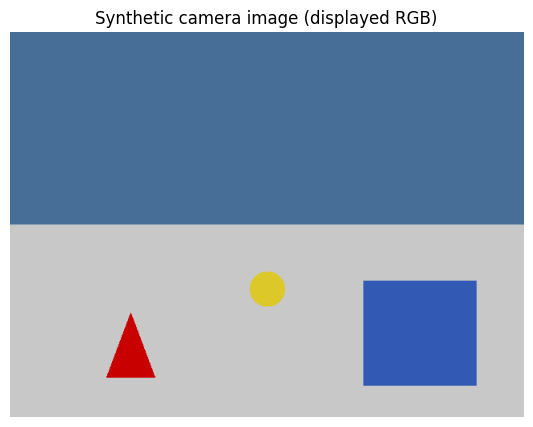

Image shape: (480, 640, 3)  (H, W, channels; stored BGR)


In [14]:
def synthetic_scene(width=640, height=480, seed=0):
    """Build a BGR image with a red cone (left), a yellow ball (center),
    and a blue box (right) on a gray floor under a bluish sky."""
    img = np.full((height, width, 3), (200, 200, 200), dtype=np.uint8)      # floor (BGR)
    img[: height // 2, :] = (150, 110, 70)                                  # sky (BGR bluish-brown)
    # Red cone on the LEFT (BGR red = (0, 0, 200))
    cone = np.array([[150, 350], [120, 430], [180, 430]], dtype=np.int32)
    cv2.drawContours(img, [cone], 0, (0, 0, 200), thickness=cv2.FILLED)
    # Yellow ball near the CENTER (BGR yellow = (40, 200, 220))
    cv2.circle(img, (320, 320), 22, (40, 200, 220), thickness=cv2.FILLED)
    # Blue box on the RIGHT (BGR blue = (180, 90, 50))
    cv2.rectangle(img, (440, 310), (580, 440), (180, 90, 50), thickness=cv2.FILLED)
    return img


img = synthetic_scene()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # matplotlib wants RGB

plt.figure(figsize=(7, 5))
plt.imshow(img_rgb)
plt.title('Synthetic camera image (displayed RGB)')
plt.axis('off')
plt.show()
print(f'Image shape: {img.shape}  (H, W, channels; stored BGR)')

### Step 4.2 --- HSV mask for red

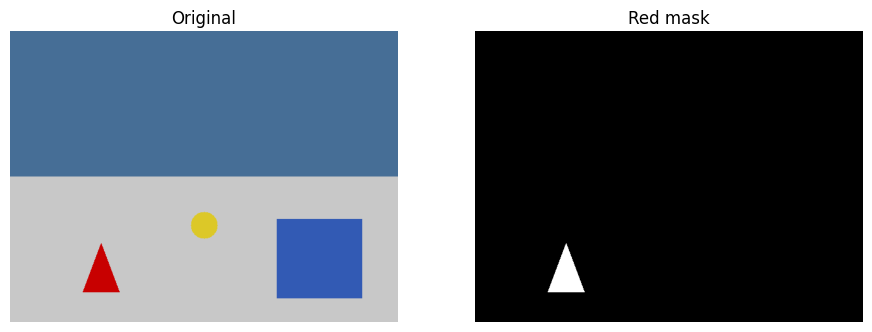

In [15]:
# TODO:
#   1. cvtColor to HSV
#   2. choose lower/upper HSV bounds for red
#   3. cv2.inRange -> binary mask
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])
mask = cv2.inRange(hsv, lower_red, upper_red)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Red mask'); axes[1].axis('off')
plt.show()

### Step 4.3 --- Find the cone: contour + bounding box + centroid

In [16]:
# TODO: find external contours in `mask`, pick the largest by area,
#       then compute its bounding box and centroid.
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# cnt = ???
# x, y, w, h = cv2.boundingRect(cnt)
# cx, cy = x + w // 2, y + h // 2

# Uncomment once the above is filled in:
# vis = img_rgb.copy()
# cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
# cv2.circle(vis, (cx, cy), 6, (255, 255, 0), -1)
# plt.figure(figsize=(7, 5))
# plt.imshow(vis)
# plt.title(f'Cone centroid at pixel ({cx}, {cy}); box {w} x {h}')
# plt.axis('off')
# plt.show()

### Step 4.4 --- Pixel to steering decision

Given the centroid, decide LEFT / STRAIGHT / RIGHT with a small dead zone around the image center.

In [17]:
# TODO: given centroid (cx, cy), decide TURN LEFT / GO STRAIGHT / TURN RIGHT.
# Use img.shape[1] for the image width and a small dead zone (e.g. 50 px).
img_center = img.shape[1] // 2
# action = ???
# print(f'Cone at pixel x = {cx}, image center = {img_center}  --> {action}')

### Step 4.5 --- LiDAR vs Camera

In 2 sentences, say what each sensor gave you that the other did not.

**Your answer:** _..._

---
## Wrap-up

Write 2--3 sentences about what surprised you:

**Your answer:** _..._